In [86]:
files = ['detection_model-time.json','extractor-time.json']

In [87]:
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [159]:
import pandas as pd
import json
import re
def load_dataframe(filename):
    with open(filename,'r') as f:
        df = pd.DataFrame(json.load(f))
        df['index'] = range(len(df))
        return df

def drop_cols(df,dropcols):
    return df[list(filter(lambda x:not re.search('|'.join(dropcols),x) ,df.columns))]

def plot_pie_chart(df,dropcols=['name','input_file','index','Total_time'],dropre=['min','max','avg'],count=None):
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    count = len(df) if count is None else count
    for i in range(count):
        dfi = df.loc[str(i),:]
        axis('equal')
        pie(dfi, labels=df.columns,startangle=0)
        show()

def plot_pie_chart_(df,dropcols=['name','index','input_file','Total_time'],dropre=['min','max','avg'],count=None,figdim=10):
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    count = len(df) if count is None else count
    rows = max(int(count/2),1)
    cols = 2 if count>1 else 1
    figsize = tuple([ figdim*rows for _ in range(rows) ])
    fig, ax = plt.subplots(rows,cols,figsize=figsize)
        
    for i in range(count):
        dfi = df.loc[str(i),:]
        ax = fig.add_subplot(rows,cols,(i%cols)+1)
        _, _ = ax.pie(dft.loc['0',:], startangle=0,labels=dft.columns)
        ax.axis('equal')

In [165]:
drop_columns = True
drop_re=['min','max'] #drop all columns that have these words
dfs = list(map(load_dataframe,files))
if drop_columns:
    dfs = list(map(lambda d:drop_cols(d,drop_re),dfs))
dfdm,dfex = dfs

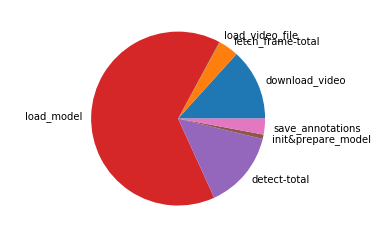

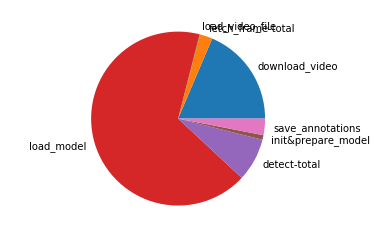

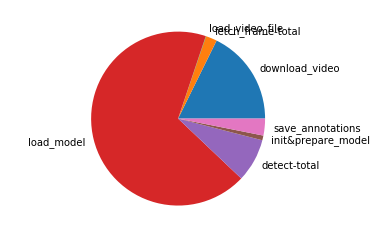

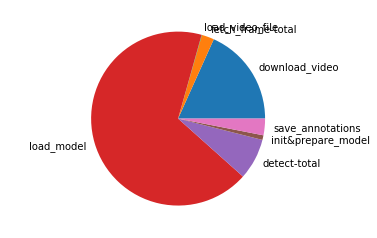

In [166]:
plot_pie_chart(dfex)

In [167]:
print(dfex.columns,'\n',dfdm.columns)

Index(['Total_time', 'download_video', 'detect-avg', 'name', 'input_file',
       'fetch_frame-total', 'load_video_file', 'load_model', 'detect-total',
       'init&prepare_model', 'save_annotations', 'fetch_frame-avg', 'index'],
      dtype='object') 
 Index(['detect-avg', 'name', 'post_detection_ops-total', 'input_file',
       'post_detection_ops-avg', 'load_model', 'import_deps', 'detect-total',
       'init_model', 'index'],
      dtype='object')


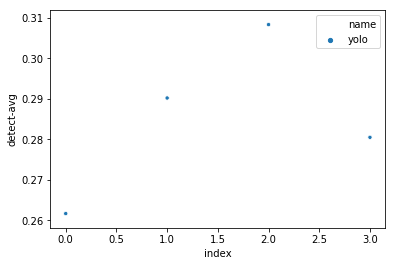

In [163]:
sns.scatterplot(data=dfex,x='index',y='detect-avg',hue='name',size='name')

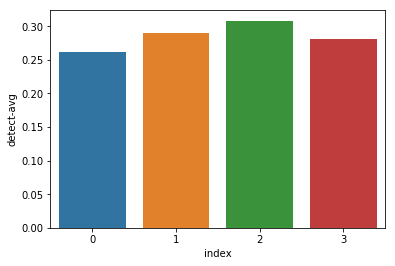

In [164]:
sns.barplot(x='index',y='detect-avg',data=dfex)